# Prospect analysis and decisions

In [1]:
from probabilit import plot, Distribution

thickness = Distribution("norm", loc=50, scale=10)

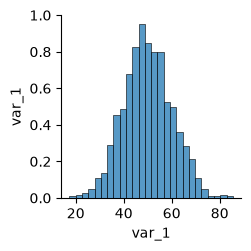

In [2]:
plot(thickness)

In [6]:
area = Distribution("norm", loc=1e6, scale=1e4)
ntg = Distribution("norm", loc=0.5, scale=0.1)
porosity = Distribution("lognorm", s=0.15, scale=0.03)
sw = Distribution("norm", loc=0.15, scale=0.01)

grv = thickness * ntg * area
hcpv = grv * porosity * (1 - sw)

samples = hcpv.sample(100, random_state=0)

x_bar = samples.mean()
x_bar

np.float64(667452.0265243015)

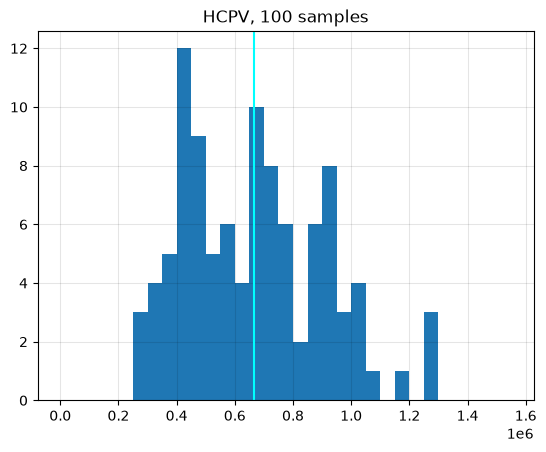

In [10]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.arange(0, 1.6e6, 5e4)

fig, ax = plt.subplots()
_ = ax.hist(samples, bins=bins)
ax.set_title("HCPV, 100 samples")
ax.axvline(x_bar, c='cyan')
ax.grid(c='k', alpha=0.1)

<Axes: ylabel='Count'>

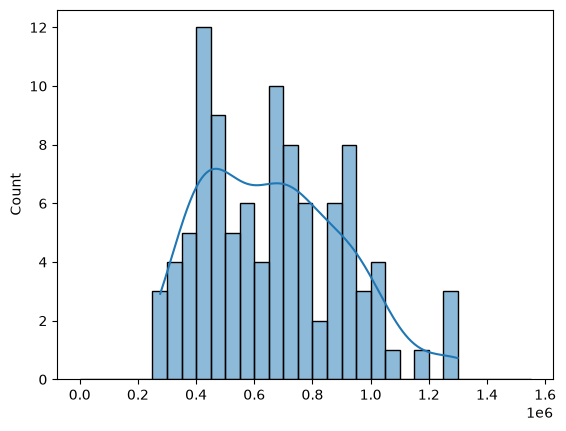

In [12]:
import seaborn as sns

sns.histplot(samples, bins=bins, kde=True)

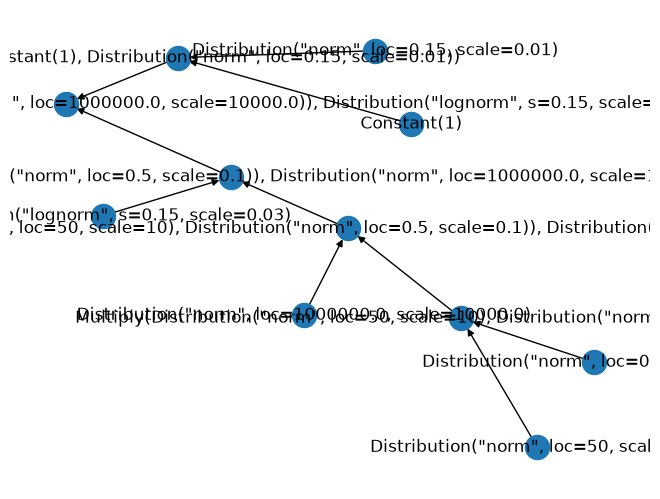

In [32]:
import networkx as nx

G = hcpv.to_graph()
nx.draw(G, with_labels=True)

In [30]:
print(G)

MultiDiGraph with 11 nodes and 10 edges


- Visualize computational graph
- 